In [14]:
nifti_files = []

for scan_dir in scan_dirs:
    scan_name = scan_dir.name
    dicom_dir = None
    for root, dirs, files in os.walk(scan_dir):
        if any(f.lower().endswith('.dcm') for f in files):
            dicom_dir = Path(root)
            break
    
    if dicom_dir:
        print(f"Converting {scan_name}:")
        try:
            dicom2nifti.convert_directory(str(dicom_dir), str(output_dir), compression=True, reorient=True)
            generated_files = sorted(output_dir.glob("*.nii.gz"), key=os.path.getmtime, reverse=True)
            if generated_files:
                new_nifti = generated_files[0]

                clean_name = scan_name.replace(" ", "_").replace("-", "_").replace(".", "") + ".nii.gz"
                final_path = output_dir / clean_name
                if new_nifti.exists() and not final_path.exists(): 
                     new_nifti.rename(final_path)
                elif final_path.exists():
                     pass 
                else:
                     final_path = new_nifti 
                
                nifti_files.append(final_path)
                print(f"Created {final_path.name}")
        except Exception as e:
            print(f"Error converting {scan_name}: {e}")
    else:
        print(f"No DICOMs found for {scan_name}")

print(f"\nTotal NIfTI files: {len(nifti_files)}")

Converting Axial_MB_rsfMRI__EYES_OPEN___MSV22_:


c:\Users\user\Desktop\MRI_eval\.venv\Lib\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: '2.16.124.113543.6006.99.0804605326103761174'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)


Created Axial_MB_rsfMRI__EYES_OPEN___MSV22_.nii.gz
Converting WIP_SOURCE_-_Axial_3D_pCASL_2000__Eyes_Open___MSV22_:
Created WIP_SOURCE___Axial_3D_pCASL_2000__Eyes_Open___MSV22_.nii.gz
Converting WIP_SOURCE_-_Axial_3D_pCASL_2500__Eyes_Open___MSV22_:
Created WIP_SOURCE___Axial_3D_pCASL_2500__Eyes_Open___MSV22_.nii.gz

Total NIfTI files: 3



Axial_MB_rsfMRI__EYES_OPEN___MSV22_.nii.gz:
BOLD map for Axial_MB_rsfMRI__EYES_OPEN___MSV22_.nii.gz:


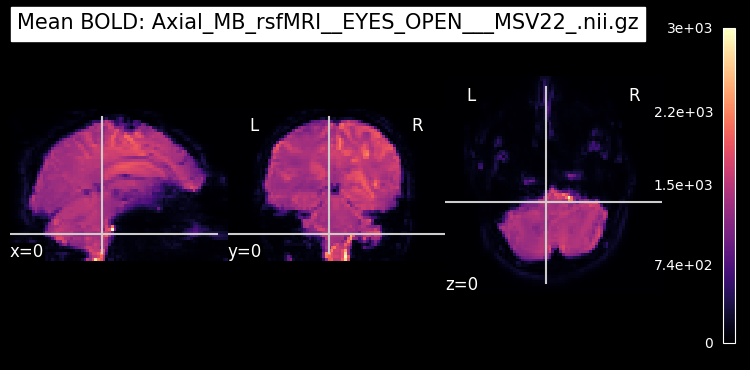

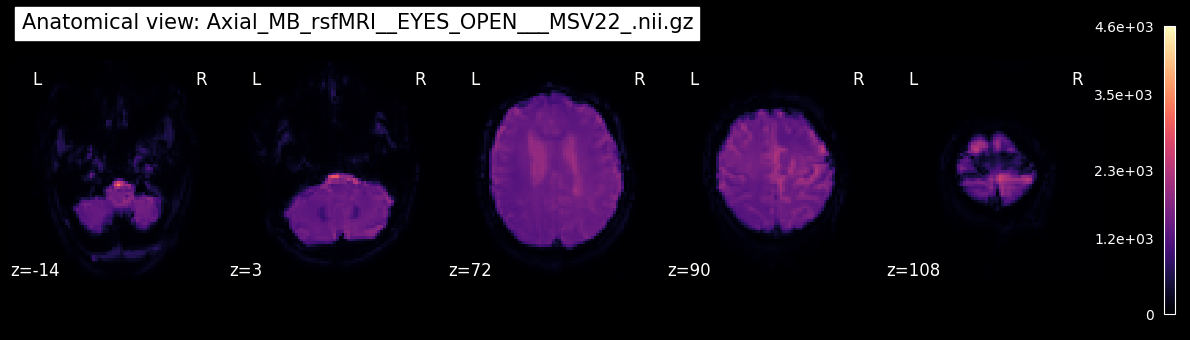

In [9]:
preprocessed_imgs = []

for nifti_path in nifti_files:
    if "rsfMRI" in nifti_path.name: 
        print(f"\n{nifti_path.name}:")
        
        img = nib.load(str(nifti_path))
   
        mean_img = image.mean_img(img)
        
        smooth_img = image.smooth_img(img, fwhm=6)
        mean_smooth_img = image.mean_img(smooth_img)
        
        mean_path = output_dir / (nifti_path.stem.split('.')[0] + "_mean.nii.gz")
        mean_img.to_filename(mean_path)
        
        print(f"BOLD map for {nifti_path.name}:")
        nlp.plot_epi(mean_img, title=f"Mean BOLD: {nifti_path.name}", display_mode='ortho', cut_coords=(0,0,0), cmap='magma')
        plt.show()
        
        nlp.plot_anat(mean_img, title=f"Anatomical view: {nifti_path.name}", display_mode='z', cut_coords=5, cmap='magma')
        plt.show()
        
        preprocessed_imgs.append(mean_path)

In [11]:
import numpy as np
import nibabel as nib
import nilearn.plotting as nlp
from nilearn import image, masking
import matplotlib.pyplot as plt


2 ASL files: ['WIP_SOURCE___Axial_3D_pCASL_2000__Eyes_Open___MSV22_.nii.gz', 'WIP_SOURCE___Axial_3D_pCASL_2500__Eyes_Open___MSV22_.nii.gz']

ASL: WIP_SOURCE___Axial_3D_pCASL_2000__Eyes_Open___MSV22_.nii.gz


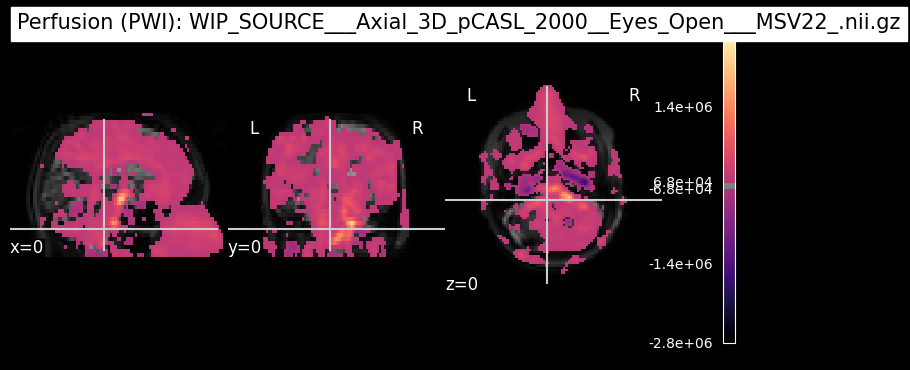

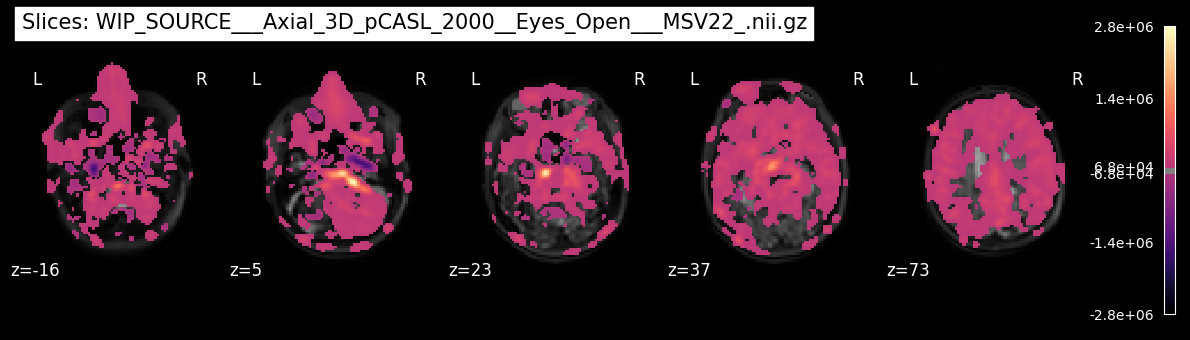


ASL: WIP_SOURCE___Axial_3D_pCASL_2500__Eyes_Open___MSV22_.nii.gz


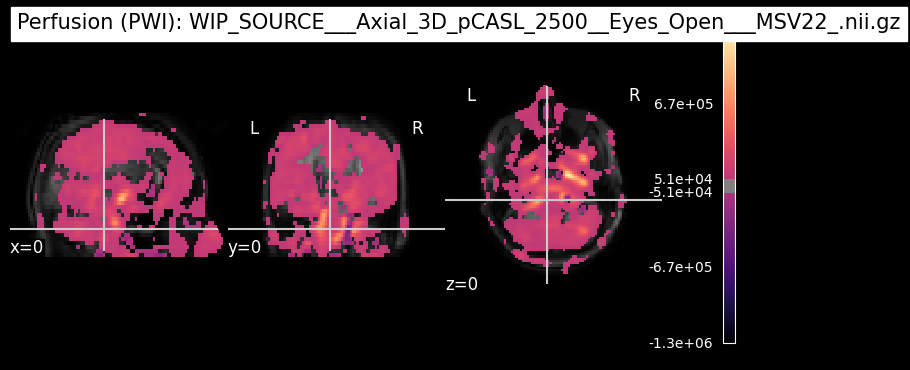

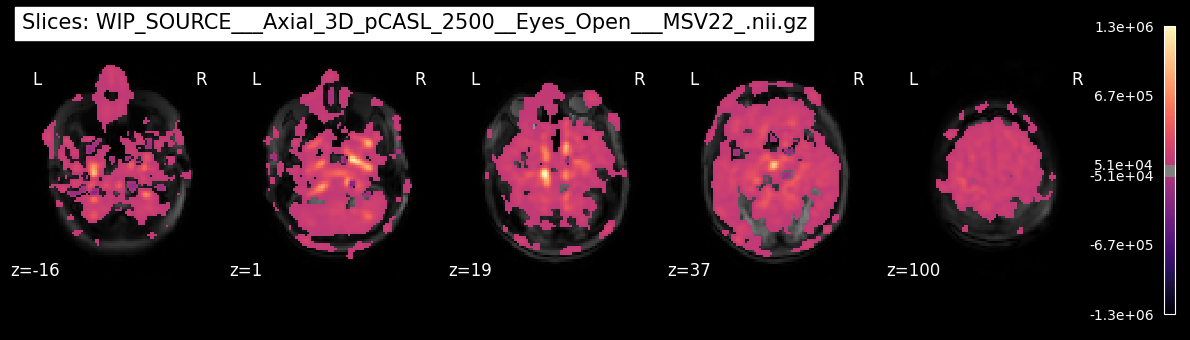

In [13]:
asl_files = [f for f in nifti_files if "pCASL" in f.name] 

print(f"{len(asl_files)} ASL files: {[f.name for f in asl_files]}")

for asl_path in asl_files: 
    print(f"\nASL: {asl_path.name}") 
    img = nib.load(str(asl_path)) 
    data = img.get_fdata()
    
    if data.ndim != 4:  #not 4D
        continue

    if data.shape[3] % 2 != 0:
        data = data[..., :-1]

    pwi_raw = np.mean(data[..., 0::2] - data[..., 1::2], axis=3)

    mask_img = masking.compute_epi_mask(image.mean_img(img))
    if np.mean(pwi_raw[mask_img.get_fdata().astype(bool)]) < 0:
        pwi_raw = -pwi_raw

    pwi_img = nib.Nifti1Image(pwi_raw, img.affine, img.header)
    pwi_smooth = image.smooth_img(pwi_img, fwhm=6)
    
    output_path = output_dir / (asl_path.stem.split('.')[0] + "_PWI_smooth.nii.gz")
    pwi_smooth.to_filename(output_path)

    mean_bg = image.mean_img(img)
    nlp.plot_stat_map(pwi_smooth, bg_img=mean_bg, title=f"Perfusion (PWI): {asl_path.name}", display_mode='ortho', cut_coords=(0,0,0), cmap='magma', threshold='auto')
    plt.show()

    nlp.plot_stat_map(pwi_smooth, bg_img=mean_bg, title=f"Slices: {asl_path.name}", display_mode='z', cut_coords=5, cmap='magma', threshold='auto')
    plt.show()

Processing: 1102_wip_source_-_axial_3d_pcasl_2000_eyes_open_msv22.nii.gz
Number of scans: 2, TR: 1.00s


C:\Users\user\AppData\Local\Temp\ipykernel_13096\383245130.py:50: UserWarning: If design matrices are supplied, [hrf_model, t_r] will be ignored.
  fmri_glm = fmri_glm.fit(img, design_matrices=design_matrix)
c:\Users\user\Desktop\MRI_eval\.venv\Lib\site-packages\nilearn\glm\regression.py:196: RuntimeWarning: divide by zero encountered in divide
  dispersion = np.sum(wresid**2, 0) / (
c:\Users\user\Desktop\MRI_eval\.venv\Lib\site-packages\nilearn\glm\regression.py:196: RuntimeWarning: invalid value encountered in divide
  dispersion = np.sum(wresid**2, 0) / (
C:\Users\user\AppData\Local\Temp\ipykernel_13096\383245130.py:60: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  plotting.plot_stat_map(z_map, bg_img=mean_img, threshold=3.0,
C:\Users\user\AppData\Local\Temp\ipykernel_13096\383245130.py:60: UserWarning: empty mask
  plotting.plot_stat_map(z_map, bg_img=mean_img, threshold=3.0,


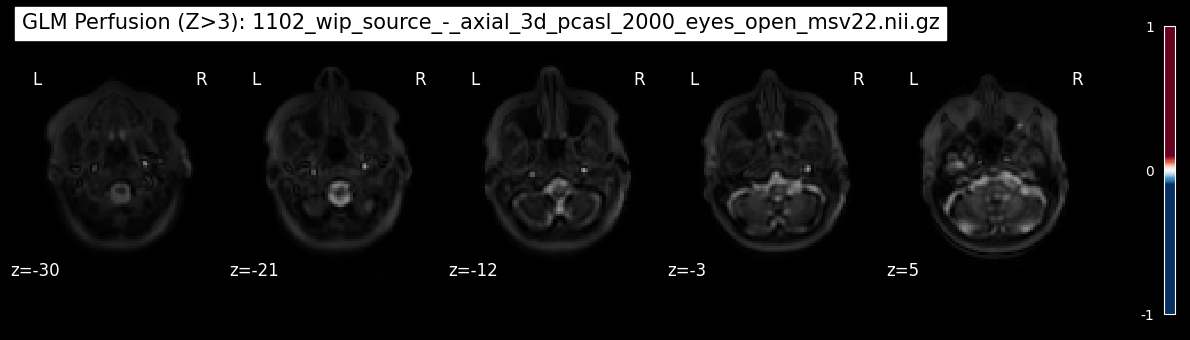

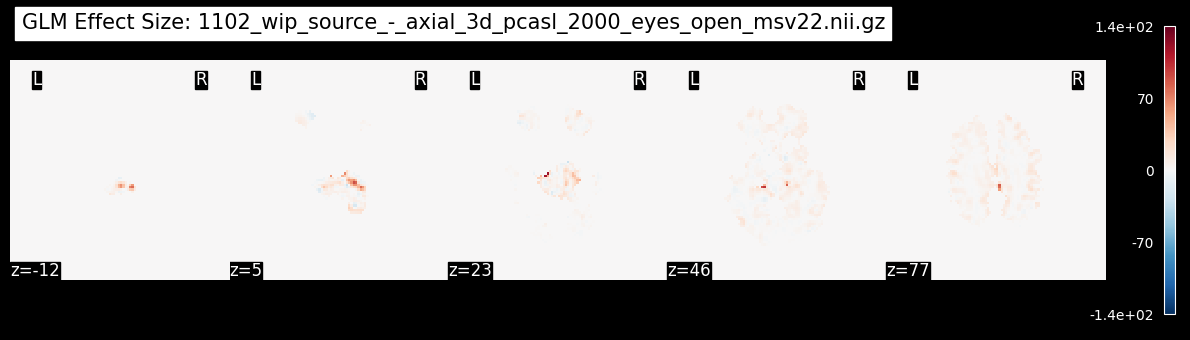

In [16]:

from nilearn.glm.first_level import FirstLevelModel
from nilearn import plotting, image
import pandas as pd


data_dir = Path("processed_data/fMRI")
output_dir = Path("processed_data/fMRI/glm_results")
output_dir.mkdir(parents=True, exist_ok=True)


pcasl_files = list(data_dir.glob("*pCASL*.nii.gz"))
pcasl_files = [f for f in pcasl_files if "PWI" not in f.name and "mean" not in f.name]


pcasl_path = pcasl_files[0]
print(f"Processing: {pcasl_path.name}")


img = nib.load(str(pcasl_path))
data = img.get_fdata()
n_scans = data.shape[3]
tr = img.header.get_zooms()[3]
print(f"Number of scans: {n_scans}, TR: {tr:.2f}s")

if n_scans % 2 != 0:
    data = data[..., :-1]
    img = nib.Nifti1Image(data, img.affine, img.header)
    n_scans -= 1

frame_times = np.arange(n_scans) * tr
conditions = np.tile([0.5, -0.5], n_scans // 2)

design_matrix = pd.DataFrame({
    'perfusion': conditions,
    'constant': np.ones(n_scans)
}, index=frame_times)

from nilearn.plotting import plot_design_matrix
plot_design_matrix(design_matrix)
plt.savefig(output_dir / "design_matrix.png")
plt.close()

fmri_glm = FirstLevelModel(t_r=tr,
                          noise_model='ar1',
                          standardize=False,
                          hrf_model=None,  
                          drift_model='cosine',
                          high_pass=0.01)

fmri_glm = fmri_glm.fit(img, design_matrices=design_matrix)

contrast_val = np.array([1, 0]) 
z_map = fmri_glm.compute_contrast(contrast_val, output_type='z_score')
eff_map = fmri_glm.compute_contrast(contrast_val, output_type='effect_size')

z_map.to_filename(output_dir / f"{pcasl_path.stem}_glm_z_map.nii.gz")
eff_map.to_filename(output_dir / f"{pcasl_path.stem}_glm_effect_map.nii.gz")

mean_img = image.mean_img(img)
plotting.plot_stat_map(z_map, bg_img=mean_img, threshold=3.0,
                      title=f"GLM Perfusion (Z>3): {pcasl_path.name}",
                      display_mode='z', cut_coords=5)
plt.savefig(output_dir / f"{pcasl_path.stem}_z_map.png")
plt.show()

plotting.plot_stat_map(eff_map, bg_img=mean_img, threshold='auto',
                      title=f"GLM Effect Size: {pcasl_path.name}",
                      display_mode='z', cut_coords=5)
plt.savefig(output_dir / f"{pcasl_path.stem}_effect_map.png")
plt.show()



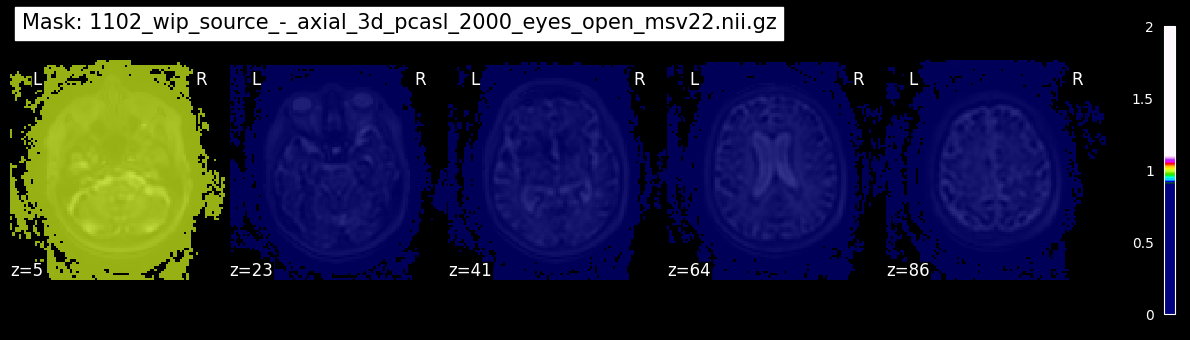

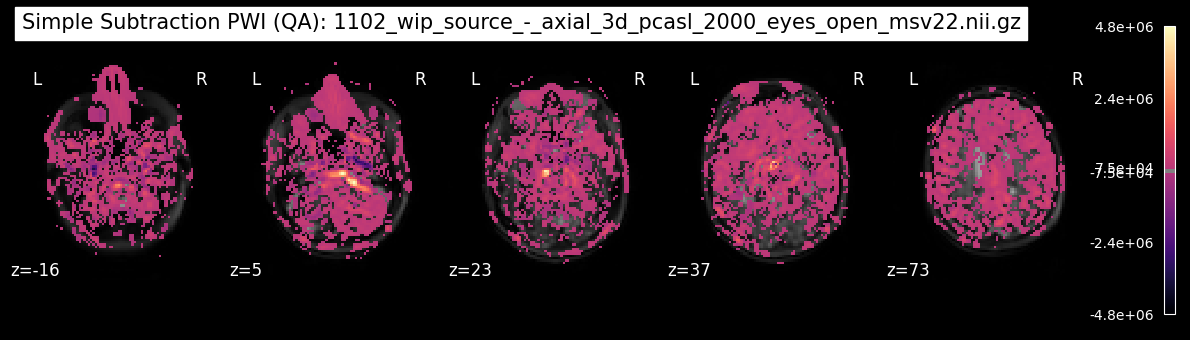

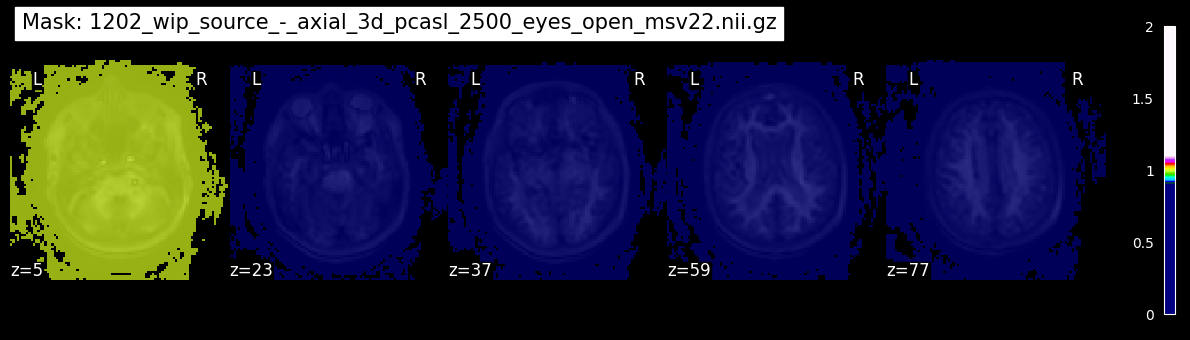

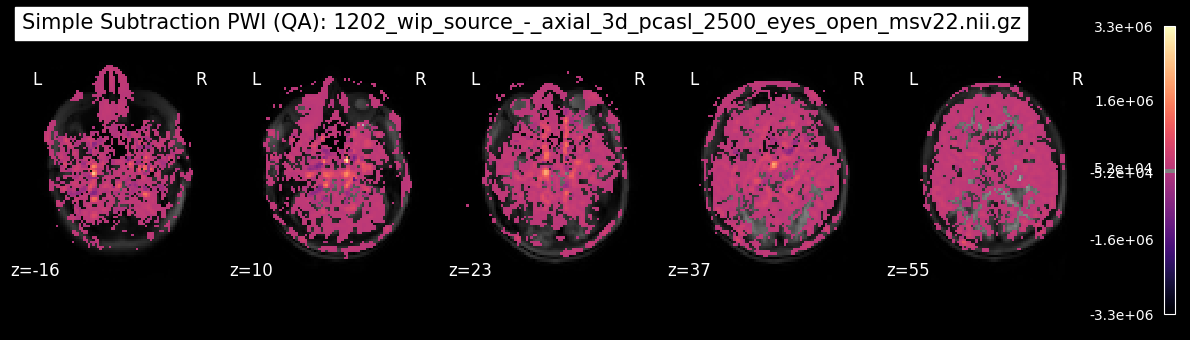

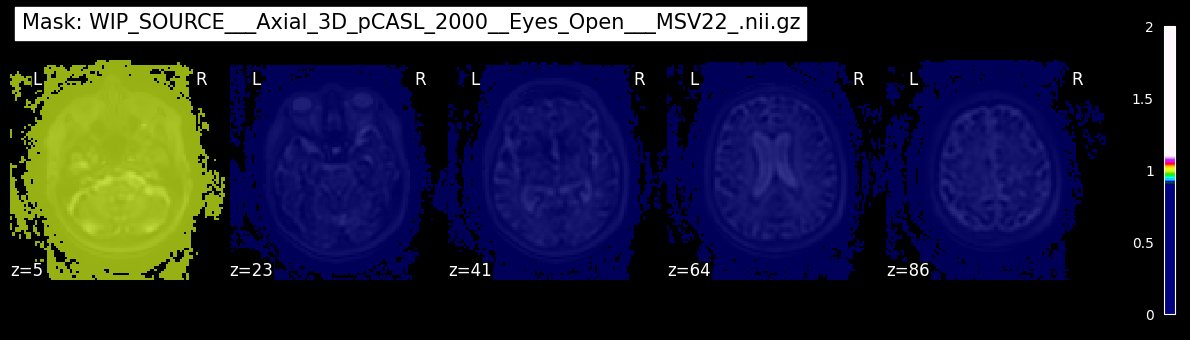

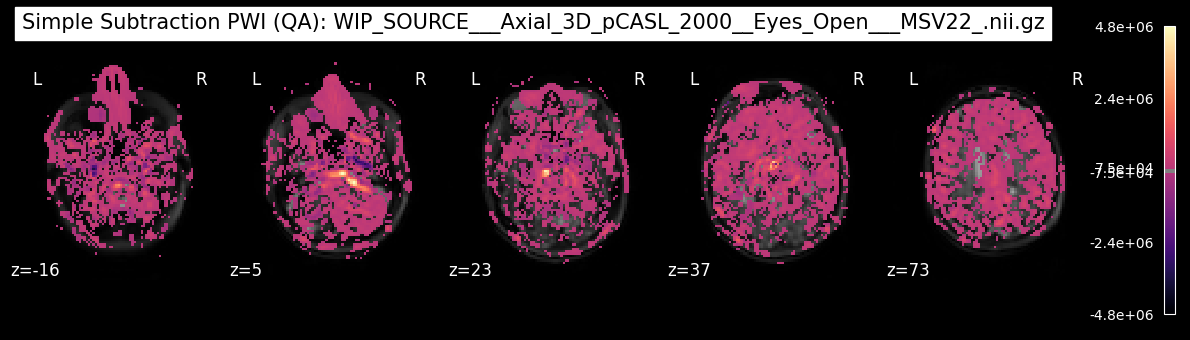

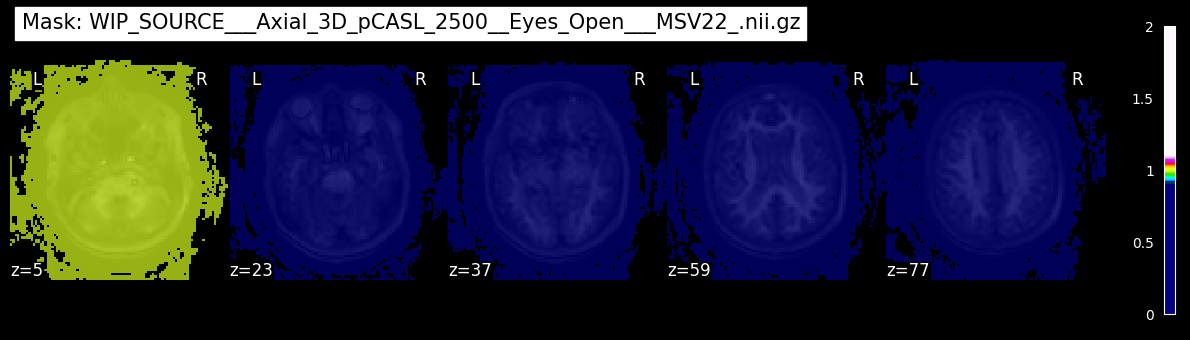

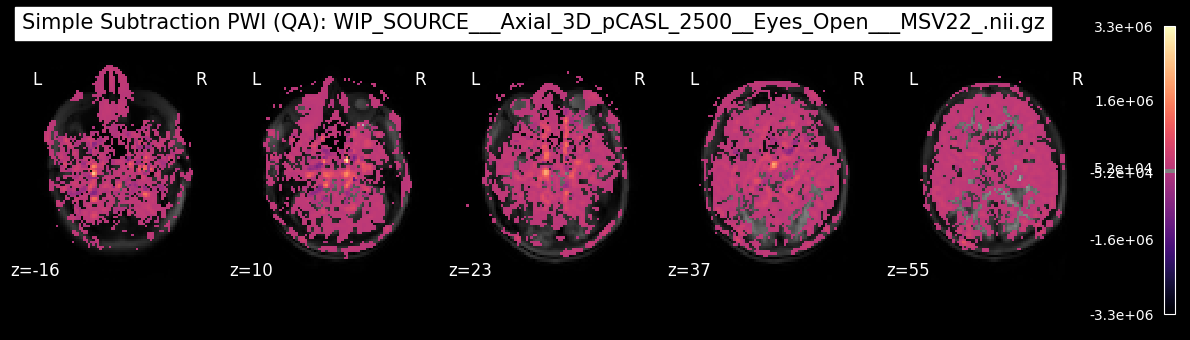

In [18]:
import numpy as np
import pandas as pd
import nibabel as nib
import scipy.ndimage as ndimage
import matplotlib.pyplot as plt
from pathlib import Path
from nilearn import image, masking
from nilearn.glm.first_level import FirstLevelModel
from nilearn.plotting import plot_design_matrix, plot_stat_map, plot_roi

data_dir = Path("processed_data/fMRI")
output_dir = Path("processed_data/fMRI/glm_results")
output_dir.mkdir(parents=True, exist_ok=True)

pcasl_files = [f for f in data_dir.glob("*pCASL*.nii.gz") if "PWI" not in f.name and "mean" not in f.name]
if not pcasl_files:
    exit()

for pcasl_path in pcasl_files:
    img = nib.load(str(pcasl_path))
    data = img.get_fdata()
    n_scans = data.shape[3]
    tr = img.header.get_zooms()[3]

    if n_scans % 2 != 0:
        data = data[..., :-1]
        img = nib.Nifti1Image(data, img.affine, img.header)
        n_scans -= 1

    mean_img = image.mean_img(img)
    mask_img = masking.compute_epi_mask(mean_img, lower_cutoff=0.2, opening=False)

    if np.sum(mask_img.get_fdata()) == 0:
        mean_data = mean_img.get_fdata()
        threshold = np.percentile(mean_data[mean_data > 0], 10)
        mask_data = ndimage.binary_fill_holes(mean_data > threshold)
        mask_img = nib.Nifti1Image(mask_data.astype(np.int8), mean_img.affine)

    plot_roi(mask_img, bg_img=mean_img, title=f"Mask: {pcasl_path.name}", display_mode='z', cut_coords=5)
    plt.savefig(output_dir / f"{pcasl_path.stem}_mask_check.png")
    plt.show()

    ctrl = data[..., 0::2]
    lbl = data[..., 1::2]
    pwi_raw = np.mean(ctrl - lbl, axis=3)
    pwi_img_qa = nib.Nifti1Image(pwi_raw, img.affine, img.header)

    plot_stat_map(pwi_img_qa, bg_img=mean_img, threshold='auto',
                  title=f"Simple Subtraction PWI (QA): {pcasl_path.name}",
                  display_mode='z', cut_coords=5, cmap='magma')
    plt.savefig(output_dir / f"{pcasl_path.stem}_simple_subtraction_qa.png")
    plt.show()

    if n_scans < 6:
        continue

    frame_times = np.arange(n_scans) * tr
    conditions = np.tile([0.5, -0.5], n_scans // 2)

    design_matrix = pd.DataFrame({
        'perfusion': conditions,
        'constant': np.ones(n_scans)
    }, index=frame_times)

    plot_design_matrix(design_matrix)
    plt.savefig(output_dir / f"{pcasl_path.stem}_design_matrix.png")
    plt.close()

    fmri_glm = FirstLevelModel(t_r=tr,
                              mask_img=mask_img,
                              noise_model='ar1',
                              standardize=False,
                              hrf_model=None, 
                              drift_model='cosine',
                              high_pass=0.01)

    fmri_glm = fmri_glm.fit(img, design_matrices=design_matrix)

    contrast_val = np.array([1, 0])
    z_map = fmri_glm.compute_contrast(contrast_val, output_type='z_score')
    eff_map = fmri_glm.compute_contrast(contrast_val, output_type='effect_size')

    z_map.to_filename(output_dir / f"{pcasl_path.stem}_glm_z_map.nii.gz")
    eff_map.to_filename(output_dir / f"{pcasl_path.stem}_glm_effect_map.nii.gz")

    plot_stat_map(z_map, bg_img=mean_img, threshold=2.3,
                  title=f"GLM Perfusion (Z>2.3): {pcasl_path.name}",
                  display_mode='z', cut_coords=5, cmap='magma')
    plt.savefig(output_dir / f"{pcasl_path.stem}_z_map.png")
    plt.show()

    plot_stat_map(eff_map, bg_img=mean_img, threshold='auto',
                  title=f"GLM Effect Size: {pcasl_path.name}",
                  display_mode='z', cut_coords=5, cmap='magma')
    plt.savefig(output_dir / f"{pcasl_path.stem}_effect_map.png")
    plt.show()